# Numba-fast phase-gate CSB fault-tolerance scaling

This notebook uses the unified `logical_csb.py` module and the Numba-compiled
stochastic-Pauli trajectory kernel for deep phase-gate CSB circuits.


State-preparation convention:

- the encoded reference state $\ket{0_L}$ is initialized ideally;
- any logical gates required to prepare the CSB input state are noisy;
- FTEC is applied after each logical preparation gate;
- measurement-basis rotations and logical readout remain noisy.

In [1]:
import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

# logical_csb.py should be in the same folder as this notebook.
sys.path.insert(0, str(Path.cwd()))

import logical_csb as sim
importlib.reload(sim)

print("Imported unified module from:", sim.__file__)
print("Numba available:", sim.using_numba())

required_functions = [
    "get_or_build_decoder",
    "get_worker_decoder",
    "make_homogeneous_noise",
    "get_csb_branches",
    "simulate_csb_point",
    "warmup_numba",
    "merge_enhanced_quadratures",
    "fit_complex_csb_eigenvalue",
    "fit_axis_decay_signed_continuous",
    "process_fidelity_from_complex_offdiag",
]
missing = [name for name in required_functions if not hasattr(sim, name)]
if missing:
    raise RuntimeError(f"Missing required functions in logical_csb.py: {missing}")

print("All required functions are available.")


Imported unified module from: /home/jovyan/logical csb/logical_csb.py
Numba available: True
All required functions are available.


## Settings

Edit this cell first.

`NOISE_REP_SCHEDULE` controls both the physical noise strengths and the CSB repetition factor used at that noise strength. For each row:

```python
{"p": physical_noise_strength, "rep": repetition_factor}
```

The true repeated-cycle depths used in fitting are:

$
L = {\rm rep}\times{\rm step}.
$

You can optionally give one noise strength its own depth steps:

```python
{"p": 1e-5, "rep": 10001, "steps": [0, 1, 2, 3, 4, 6, 8, 10, 12]}
```

The reported `*_std` values are run-to-run standard deviations.


In [2]:
# ============================================================
# Basic randomness and parallelization
# ============================================================
BASE_SEED = 1234
SEED_STRIDE = 1000003
N_JOBS = -1

# ============================================================
# Target logical cycle
# ============================================================
TARGET_GATE = "RZ90"

# ============================================================
# Physical noise strengths and per-noise CSB repetition factors
# ============================================================
NOISE_REP_SCHEDULE = [
    {"p": 1e-5, "rep": 10001},
    {"p": 3e-5, "rep": 1001},
    {"p": 1e-4, "rep": 101},
    {"p": 3e-4, "rep": 9},
    {"p": 1e-3, "rep": 1},
]

# Default step list. Individual rows in NOISE_REP_SCHEDULE may override it.
CSB_STEPS = list(range(0, 13))

# CSB shots. For enhanced offdiagonal CSB, real/imag quadratures split this in half.
CSB_SHOTS = 1000

# Split each CSB branch/depth into shot chunks for parallel execution.
# For CSB_SHOTS=1000, use 50--100.
# For CSB_SHOTS=5000--10000, use 200--500.
CSB_CHUNK_SHOTS = 100

# Independent repeats at each physical noise strength.
N_SCALING_REPEATS = 10

# ============================================================
# Physical noise model
# ============================================================
TWO_QUBIT_FACTOR = 2.0
FINAL_MEAS_FACTOR = 1.0

# ============================================================
# Decoder / FTEC implementation
# ============================================================
MIN_EC_ROUNDS = 2
MAX_EC_ROUNDS = 4
DECODER_CACHE = "steane_flag_decoder_stabilizer_max4.pkl"

# ============================================================
# Logical preparation, repeated cycle, and readout
# ============================================================
# The encoded reference state |0_L> is ideal by construction in logical_csb.py.
# Other CSB input states are prepared from |0_L> using these settings.
PREP_LOGICAL_GATES_NOISY = True
PREP_QEC_AFTER_LOGICAL_GATE = True

MEASUREMENT_BASIS_GATES_NOISY = True
QEC_AFTER_EACH_LOGICAL_GATE = True
FALLBACK_ON_UNVERIFIED = True

CIRCUIT_OPTIONS = {
    "prep_gates_noisy": PREP_LOGICAL_GATES_NOISY,
    "prep_qec_after_gate": PREP_QEC_AFTER_LOGICAL_GATE,
    "measurement_basis_gates_noisy": MEASUREMENT_BASIS_GATES_NOISY,
    "qec_after_each_logical_gate": QEC_AFTER_EACH_LOGICAL_GATE,
    "fallback_on_unverified": FALLBACK_ON_UNVERIFIED,
}

# ============================================================
# Fit and plotting settings
# ============================================================
FIT_MAX_NOISE_STRENGTH = 1e-2
SAVE_PLOTS = True
PLOT_DPI = 300
SHOW_PROGRESS = True
JOBLIB_VERBOSE = 10

schedule_df = pd.DataFrame(NOISE_REP_SCHEDULE)
schedule_df["steps"] = schedule_df.apply(
    lambda row: row["steps"] if ("steps" in row and isinstance(row["steps"], list)) else CSB_STEPS,
    axis=1,
)
schedule_df["true_depths"] = schedule_df.apply(
    lambda row: [int(row["rep"]) * int(s) for s in row["steps"]],
    axis=1,
)
schedule_df["max_depth"] = schedule_df["true_depths"].apply(max)

settings_df = pd.DataFrame([{
    "target_gate": TARGET_GATE,
    "csb_shots_requested": CSB_SHOTS,
    "offdiag_quadrature_shots": CSB_SHOTS // 2,
    "axis_shots": CSB_SHOTS,
    "n_scaling_repeats": N_SCALING_REPEATS,
    "csb_chunk_shots": CSB_CHUNK_SHOTS,
    "two_qubit_factor": TWO_QUBIT_FACTOR,
    "final_meas_factor": FINAL_MEAS_FACTOR,
    "prep_logical_gates_noisy": PREP_LOGICAL_GATES_NOISY,
    "prep_qec_after_logical_gate": PREP_QEC_AFTER_LOGICAL_GATE,
    "measurement_basis_gates_noisy": MEASUREMENT_BASIS_GATES_NOISY,
    "qec_after_each_logical_gate": QEC_AFTER_EACH_LOGICAL_GATE,
    "fallback_on_unverified": FALLBACK_ON_UNVERIFIED,
    "fit_max_noise_strength": FIT_MAX_NOISE_STRENGTH,
    "base_seed": BASE_SEED,
    "seed_stride": SEED_STRIDE,
    "n_jobs": N_JOBS,
}])

display(settings_df)
display(schedule_df)


,target_gate,csb_shots_requested,offdiag_quadrature_shots,axis_shots,n_scaling_repeats,csb_chunk_shots,two_qubit_factor,final_meas_factor,prep_logical_gates_noisy,prep_qec_after_logical_gate,measurement_basis_gates_noisy,qec_after_each_logical_gate,fallback_on_unverified,fit_max_noise_strength,base_seed,seed_stride,n_jobs
0,RZ90,1000,500,1000,10,100,2.0,1.0,True,True,True,True,True,0.01,1234,1000003,-1


,p,rep,steps,true_depths,max_depth
0,0.00001,10001,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[0, 10001, 20002, 30003, 40004, 50005, 60006, ...",120012
1,0.00003,1001,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[0, 1001, 2002, 3003, 4004, 5005, 6006, 7007, ...",12012
2,0.00010,101,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[0, 101, 202, 303, 404, 505, 606, 707, 808, 90...",1212
3,0.00030,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[0, 9, 18, 27, 36, 45, 54, 63, 72, 81, 90, 99,...",108
4,0.00100,1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",12


## Helper functions

In [3]:

def wrap_to_pi(x):
    """Wrap angles to (-pi, pi]. Works for scalars and numpy arrays."""
    arr = np.asarray(x, dtype=float)
    return (arr + np.pi) % (2 * np.pi) - np.pi


def make_noise(strength):
    return sim.make_homogeneous_noise(
        strength=float(strength),
        two_qubit_factor=TWO_QUBIT_FACTOR,
        final_meas_factor=FINAL_MEAS_FACTOR,
    )


def run_single_gate_csb_spectrum(
    decoder,
    noise,
    target_gate=TARGET_GATE,
    steps=CSB_STEPS,
    rep=1,
    shots=CSB_SHOTS,
    seed=BASE_SEED,
    show_progress=True,
    verbose=False,
):
    # Run CSB only for one target logical gate.
    # The true repeated-cycle depth used for fitting is depth = rep * step.
    rng = np.random.default_rng(int(seed))
    rows = []
    branches = sim.get_csb_branches(target_gate)

    tasks = []
    for branch_name, branch_spec in branches.items():
        for step in steps:
            tasks.append((branch_name, branch_spec, int(step)))

    iterator = tqdm(
        tasks,
        desc=f"{target_gate} CSB points, rep={rep}",
        leave=False,
        disable=not show_progress,
    )

    for branch_name, branch_spec, step in iterator:
        if branch_spec["kind"].startswith("equatorial"):
            branch_shots = max(1, int(shots) // 2)
        else:
            branch_shots = int(shots)

        depth = int(rep) * int(step)
        point_seed = int(rng.integers(2**32 - 1))

        mean, se, unv = sim.simulate_csb_point(
            decoder,
            noise,
            CIRCUIT_OPTIONS,
            target_gate,
            branch_name,
            depth,
            branch_shots,
            point_seed,
        )

        rows.append({
            "target_gate": target_gate,
            "branch": branch_name,
            "branch_kind": branch_spec["kind"],
            "initial": branch_spec["initial"],
            "measure": branch_spec["measure"],
            "measure_sign": int(branch_spec.get("measure_sign", +1)),
            "step": int(step),
            "rep": int(rep),
            "depth": int(depth),
            "mean": float(mean),
            "stderr": float(se),
            "shots": int(branch_shots),
            "requested_total_shots": int(shots),
            "unverified_rate": float(unv),
            "seed": point_seed,
        })

        if verbose:
            print(
                f"CSB {target_gate:4s} {branch_name:8s} "
                f"step {step:3d} rep {rep:4d} depth {depth:6d} "
                f"shots {branch_shots:6d} mean {mean:+.6f} stderr {se:.6f}"
            )

    return pd.DataFrame(rows)


def fit_single_gate_csb(csb_df, target_gate=TARGET_GATE):
    # Fit one target-gate CSB spectrum.
    q = sim.merge_enhanced_quadratures(csb_df, target_gate)
    complex_fit = sim.fit_complex_csb_eigenvalue(q, omega0=np.pi / 2)

    axis = csb_df[
        (csb_df["target_gate"] == target_gate) & (csb_df["branch"] == "axis")
    ].sort_values("depth")

    axis_fit = sim.fit_axis_decay_signed_continuous(
        axis["depth"].to_numpy(),
        axis["mean"].to_numpy(),
        stderr=axis["stderr"].to_numpy(),
    )

    g_off = float(complex_fit["g"])
    delta = float(wrap_to_pi(complex_fit["delta_theta"]))
    g_axis = float(axis_fit["f"])

    fidelity = sim.process_fidelity_from_complex_offdiag(
        g_offdiag=g_off,
        delta_theta=delta,
        g_axis=g_axis,
    )

    return {
        "target_gate": target_gate,
        "g_offdiag": g_off,
        "delta_theta": delta,
        "abs_delta_theta": float(abs(delta)),
        "delta_theta_squared": float(delta * delta),
        "g_axis": g_axis,
        "process_fidelity": fidelity["process_fidelity"],
        "process_infidelity": fidelity["process_infidelity"],
        "average_gate_fidelity": fidelity["average_gate_fidelity"],
        "average_gate_infidelity": fidelity["average_gate_infidelity"],
        "offdiag_decay_rate": -np.log(max(g_off, 1e-15)),
        "axis_decay_rate": -np.log(max(abs(g_axis), 1e-15)),
        "complex_fit_success": bool(complex_fit.get("success", False)),
        "complex_fit_cost": float(complex_fit.get("cost", np.nan)),
        "axis_amplitude": float(axis_fit.get("A", np.nan)),
        "axis_fit_success": bool(axis_fit.get("success", False)),
        "axis_fit_cost": float(axis_fit.get("cost", np.nan)),
        "mean_unverified_rate": float(csb_df["unverified_rate"].mean()),
    }


def summarize_repeats(df):
    df = df.copy()

    # delta_theta is a signed coherent bias.  For an "angle error magnitude"
    # plot, use abs_delta_theta_mean or rms_delta_theta, not delta_theta_mean.
    if "delta_theta" in df.columns:
        df["delta_theta"] = wrap_to_pi(df["delta_theta"].to_numpy(dtype=float))
        df["abs_delta_theta"] = np.abs(df["delta_theta"].to_numpy(dtype=float))
        df["delta_theta_squared"] = df["delta_theta"].to_numpy(dtype=float) ** 2

    value_cols = [
        "g_offdiag",
        "delta_theta",           # signed coherent angle bias
        "abs_delta_theta",       # magnitude of coherent angle error
        "delta_theta_squared",   # used to compute RMS angle error
        "g_axis",
        "process_fidelity",
        "process_infidelity",
        "average_gate_infidelity",
        "offdiag_decay_rate",
        "axis_decay_rate",
        "mean_unverified_rate",
    ]

    rows = []
    for p, sub in df.groupby("physical_noise_strength"):
        row = {
            "physical_noise_strength": float(p),
            "n_repeats": int(sub["repeat_id"].nunique()),
            "rep": int(sub["rep"].iloc[0]),
            "max_depth": int(sub["max_depth"].iloc[0]),
        }
        for col in value_cols:
            if col not in sub.columns:
                continue
            vals = sub[col].to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue
            row[f"{col}_mean"] = float(np.mean(vals))
            row[f"{col}_std"] = float(np.std(vals, ddof=1)) if len(vals) >= 2 else np.nan
        rows.append(row)

    summary = pd.DataFrame(rows).sort_values("physical_noise_strength").reset_index(drop=True)

    if "delta_theta_squared_mean" in summary.columns:
        summary["rms_delta_theta"] = np.sqrt(
            np.maximum(summary["delta_theta_squared_mean"].to_numpy(dtype=float), 0.0)
        )

    return summary


def summarize_raw_csb_signals(csb_all_df):
    rows = []
    group_cols = ["physical_noise_strength", "target_gate", "branch", "rep", "step", "depth"]
    for key, sub in csb_all_df.groupby(group_cols):
        row = dict(zip(group_cols, key))
        row["n_repeats"] = int(sub["repeat_id"].nunique())
        row["mean_of_mean"] = float(sub["mean"].mean())
        row["std_of_mean"] = float(sub["mean"].std(ddof=1)) if len(sub) >= 2 else np.nan
        row["mean_stderr_shot"] = float(sub["stderr"].mean())
        row["mean_unverified_rate"] = float(sub["unverified_rate"].mean())
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["physical_noise_strength", "branch", "depth"]).reset_index(drop=True)


## Run physical-noise-strength scan, fast chunked-parallel version

This cell is the main speedup.

Each CSB point is split into shot chunks. For example, if `CSB_SHOTS=1000` and `CSB_CHUNK_SHOTS=100`, then:

- `eq_real` uses 500 shots → 5 parallel chunk jobs;
- `eq_imag` uses 500 shots → 5 parallel chunk jobs;
- `axis` uses 1000 shots → 10 parallel chunk jobs.

This makes deep points use all workers, instead of leaving one worker stuck with the entire deepest circuit.


In [4]:

from joblib import Parallel, delayed

# Build/load decoder cache once before workers start.
# Each worker will then call sim.get_worker_decoder() and reuse its local cached decoder.
decoder = sim.get_or_build_decoder(
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    verbose=True,
)

# Compile/warm up the Numba kernel once in the main process.
# The first call pays compilation cost; later calls use compiled/cache code.
print("Warming up Numba CSB kernel...")
print(
    "warmup result:",
    sim.warmup_numba(
        decoder,
        make_noise(NOISE_REP_SCHEDULE[-1]["p"]),
        CIRCUIT_OPTIONS,
        seed=BASE_SEED,
    ),
)

branches = sim.get_csb_branches(TARGET_GATE)

def _split_shots(total_shots, chunk_shots):
    total_shots = int(total_shots)
    chunk_shots = max(1, int(chunk_shots))
    chunks = []
    left = total_shots
    while left > 0:
        n = min(chunk_shots, left)
        chunks.append(n)
        left -= n
    return chunks


def _branch_total_shots(branch_spec):
    if branch_spec["kind"].startswith("equatorial"):
        return max(1, int(CSB_SHOTS) // 2)
    return int(CSB_SHOTS)


point_tasks = []
chunk_tasks = []

for i, cfg in enumerate(NOISE_REP_SCHEDULE):
    p = float(cfg["p"])
    rep_p = int(cfg.get("rep", 1))
    steps_p = cfg.get("steps", CSB_STEPS)
    max_depth_p = int(rep_p * max(steps_p))

    for r in range(N_SCALING_REPEATS):
        repeat_seed = int(BASE_SEED + i * 100000000 + r * SEED_STRIDE)

        for bidx, (branch_name, branch_spec) in enumerate(branches.items()):
            total_branch_shots = _branch_total_shots(branch_spec)

            for step in steps_p:
                step = int(step)
                depth = int(rep_p * step)
                point_id = len(point_tasks)

                point_meta = {
                    "point_id": int(point_id),
                    "target_gate": TARGET_GATE,
                    "physical_noise_strength": float(p),
                    "rep": int(rep_p),
                    "max_depth": int(max_depth_p),
                    "repeat_id": int(r),
                    "repeat_seed": int(repeat_seed),
                    "branch_idx": int(bidx),
                    "branch": branch_name,
                    "branch_kind": branch_spec["kind"],
                    "initial": branch_spec["initial"],
                    "measure": branch_spec["measure"],
                    "measure_sign": int(branch_spec.get("measure_sign", +1)),
                    "step": int(step),
                    "depth": int(depth),
                    "requested_total_shots": int(CSB_SHOTS),
                    "total_branch_shots": int(total_branch_shots),
                }
                point_tasks.append(point_meta)

                for chunk_id, chunk_shots in enumerate(_split_shots(total_branch_shots, CSB_CHUNK_SHOTS)):
                    # Deterministic but distinct seed for each independent chunk.
                    point_seed = int(
                        repeat_seed
                        + 1000003 * int(bidx)
                        + 9176 * int(step)
                        + 2654435761 * int(chunk_id)
                    ) % (2**32 - 1)

                    task = dict(point_meta)
                    task["chunk_id"] = int(chunk_id)
                    task["chunk_shots"] = int(chunk_shots)
                    task["seed"] = int(point_seed)
                    chunk_tasks.append(task)

print(f"Total CSB points = {len(point_tasks)}")
print(f"Total chunk jobs = {len(chunk_tasks)}")
print(f"N_JOBS = {N_JOBS}")
print(f"CSB_CHUNK_SHOTS = {CSB_CHUNK_SHOTS}")


def run_one_csb_chunk(task):
    decoder_local = sim.get_worker_decoder(
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
    )
    noise_p = make_noise(float(task["physical_noise_strength"]))

    mean, se, unv = sim.simulate_csb_point(
        decoder_local,
        noise_p,
        CIRCUIT_OPTIONS,
        TARGET_GATE,
        task["branch"],
        int(task["depth"]),
        int(task["chunk_shots"]),
        int(task["seed"]),
    )

    out = dict(task)
    out["mean"] = float(mean)
    out["stderr"] = float(se)
    out["shots"] = int(task["chunk_shots"])
    out["unverified_rate"] = float(unv)
    return out


chunk_rows = Parallel(
    n_jobs=N_JOBS,
    backend="loky",
    verbose=JOBLIB_VERBOSE,
    batch_size=1,
)(
    delayed(run_one_csb_chunk)(task)
    for task in chunk_tasks
)

csb_chunk_raw_df = pd.DataFrame(chunk_rows)


def combine_chunked_point(sub):
    sub = sub.sort_values("chunk_id")
    shots = sub["shots"].to_numpy(dtype=float)
    means = sub["mean"].to_numpy(dtype=float)
    stderrs = sub["stderr"].to_numpy(dtype=float)

    total_shots = int(np.sum(shots))
    mean = float(np.sum(shots * means) / max(total_shots, 1))

    # Reconstruct within-chunk sample variances from stderr_i = sqrt(var_i / n_i).
    # Combine within- and between-chunk variance.
    if total_shots > 1 and len(sub) > 0:
        variances = (stderrs * np.sqrt(np.maximum(shots, 1.0))) ** 2
        ss_within = float(np.sum(np.maximum(shots - 1.0, 0.0) * variances))
        ss_between = float(np.sum(shots * (means - mean) ** 2))
        sample_var = max(0.0, (ss_within + ss_between) / max(total_shots - 1, 1))
        stderr = float(np.sqrt(sample_var / total_shots))
    else:
        stderr = 0.0

    # unverified_rate returned by simulate_csb_point is per EC cycle.
    # Weighting by shots is a good approximation for fixed branch/depth.
    unv = float(np.sum(shots * sub["unverified_rate"].to_numpy(dtype=float)) / max(total_shots, 1))

    first = sub.iloc[0].to_dict()

    keep_keys = [
        "target_gate",
        "physical_noise_strength",
        "rep",
        "max_depth",
        "repeat_id",
        "repeat_seed",
        "branch",
        "branch_kind",
        "initial",
        "measure",
        "measure_sign",
        "step",
        "depth",
        "requested_total_shots",
    ]
    row = {k: first[k] for k in keep_keys}
    row["mean"] = mean
    row["stderr"] = stderr
    row["shots"] = total_shots
    row["unverified_rate"] = unv
    # Keep the first chunk seed only as a reproducibility marker.
    row["seed"] = int(first["seed"])
    row["n_chunks"] = int(len(sub))
    return row


combined_rows = []
for point_id, sub in csb_chunk_raw_df.groupby("point_id"):
    combined_rows.append(combine_chunked_point(sub))

scaling_csb_raw_df = pd.DataFrame(combined_rows).sort_values(
    ["physical_noise_strength", "repeat_id", "branch", "depth"]
).reset_index(drop=True)

records = []
for (p, r), sub in scaling_csb_raw_df.groupby(["physical_noise_strength", "repeat_id"]):
    fit_p = fit_single_gate_csb(sub, target_gate=TARGET_GATE)

    fit_p["physical_noise_strength"] = float(p)
    fit_p["rep"] = int(sub["rep"].iloc[0])
    fit_p["max_depth"] = int(sub["max_depth"].iloc[0])
    fit_p["repeat_id"] = int(r)
    fit_p["seed"] = int(sub["repeat_seed"].iloc[0])

    records.append(fit_p)

scaling_raw_df = pd.DataFrame(records)
scaling_summary_df = summarize_repeats(scaling_raw_df)
csb_signal_summary_df = summarize_raw_csb_signals(scaling_csb_raw_df)

display(scaling_summary_df)
display(csb_signal_summary_df.head())


# Numerical results remain in memory; no CSV files are written.


Loaded verified flagged Steane EC decoder.
  decoder bins     = 445
Warming up Numba CSB kernel...
warmup result: (1.0, 0.0, 0.0)
Total CSB points = 1950
Total chunk jobs = 13000
N_JOBS = -1
CSB_CHUNK_SHOTS = 100


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done  58 tasks      | elapsed:   28.0s
[Parallel(n_jobs=-1)]: Done  73 tasks      | elapsed:   31.2s
[Parallel(n_jobs=-1)]: Done  88 tasks      | elapsed:   35.0s
[Parallel(n_jobs=-1)]: Done 105 tasks      | elapsed:   40.5s
[Parallel(n_jobs=-1)]: Done 122 tasks      | elapsed:   45.8s
[Parallel(n_jobs=-1)]: Done 141 tasks      | elapsed:   49.3s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:   53.6s
[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   58.9s
[Parallel(n_jobs=-1)]: Done 202 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 225 tasks      | elapsed:  

,physical_noise_strength,n_repeats,rep,max_depth,g_offdiag_mean,g_offdiag_std,delta_theta_mean,delta_theta_std,abs_delta_theta_mean,abs_delta_theta_std,...,process_infidelity_std,average_gate_infidelity_mean,average_gate_infidelity_std,offdiag_decay_rate_mean,offdiag_decay_rate_std,axis_decay_rate_mean,axis_decay_rate_std,mean_unverified_rate_mean,mean_unverified_rate_std,rms_delta_theta
0,0.00001,10,10001,120012,0.999995,2.805333e-07,1.518541e-07,3.705696e-07,3.435929e-07,1.782422e-07,...,1.712545e-07,0.000002,1.141697e-07,0.000005,2.805348e-07,0.000004,3.219611e-07,0.000009,1.316473e-07,3.829482e-07
1,0.00003,10,1001,12012,0.999953,1.414694e-06,6.644149e-07,3.540630e-06,2.794631e-06,2.085383e-06,...,9.748604e-07,0.000022,6.499070e-07,0.000047,1.414762e-06,0.000039,2.107060e-06,0.000078,9.975253e-07,3.424018e-06
2,0.00010,10,101,1212,0.999494,1.631256e-05,7.433758e-06,3.367785e-05,2.610049e-05,2.094445e-05,...,1.025634e-05,0.000239,6.837559e-06,0.000506,1.632077e-05,0.000419,1.290382e-05,0.000882,3.215912e-05,3.280303e-05
3,0.00030,10,9,108,0.995710,2.023875e-04,-1.481786e-04,4.560931e-04,3.880529e-04,2.551485e-04,...,9.829656e-05,0.002004,6.553104e-05,0.004299,2.032611e-04,0.003453,1.530101e-04,0.007065,1.430825e-04,4.573573e-04
4,0.00100,10,1,12,0.961630,1.790114e-03,-6.638678e-04,3.325860e-03,2.449692e-03,2.209811e-03,...,8.192271e-04,0.018108,5.461514e-04,0.039127,1.861420e-03,0.032421,1.535435e-03,0.058144,5.292270e-04,3.224272e-03


,physical_noise_strength,target_gate,branch,rep,step,depth,n_repeats,mean_of_mean,std_of_mean,mean_stderr_shot,mean_unverified_rate
0,0.00001,RZ90,axis,10001,0,0,10,1.0000,0.000000,0.000000,0.000000
1,0.00001,RZ90,axis,10001,1,10001,10,0.9616,0.008631,0.008630,0.000009
2,0.00001,RZ90,axis,10001,2,20002,10,0.9122,0.014801,0.012915,0.000009
3,0.00001,RZ90,axis,10001,3,30003,10,0.8770,0.019760,0.015153,0.000009
4,0.00001,RZ90,axis,10001,4,40004,10,0.8494,0.009935,0.016688,0.000009


## Plot CSB spectral quantities versus physical noise

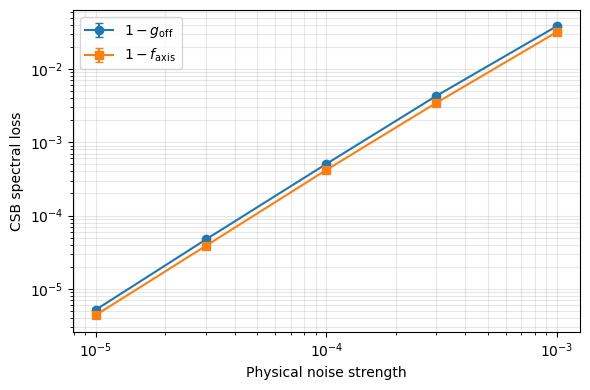

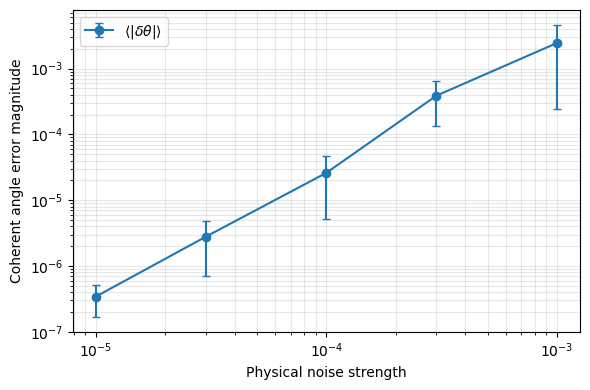

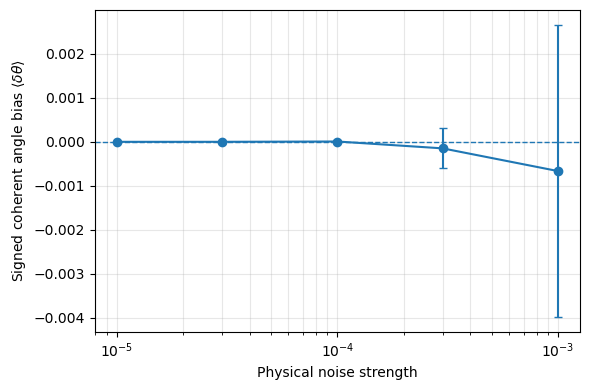

In [5]:

x = scaling_summary_df["physical_noise_strength"].to_numpy()

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    x,
    1.0 - scaling_summary_df["g_offdiag_mean"],
    yerr=scaling_summary_df["g_offdiag_std"],
    marker="o",
    capsize=3,
    label=r"$1-g_{\rm off}$",
)

ax.errorbar(
    x,
    1.0 - scaling_summary_df["g_axis_mean"],
    yerr=scaling_summary_df["g_axis_std"],
    marker="s",
    capsize=3,
    label=r"$1-f_{\rm axis}$",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Physical noise strength")
ax.set_ylabel("CSB spectral loss")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()

# if SAVE_PLOTS:
#     plt.savefig("phase_gate_csb_spectral_loss_scaling.png", dpi=PLOT_DPI, bbox_inches="tight")
#     plt.savefig("phase_gate_csb_spectral_loss_scaling.pdf", bbox_inches="tight")

plt.show()


# Signed mean is a coherent angle bias.  It can cancel across repeats.
# For error magnitude, use |delta_theta| or RMS(delta_theta).
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    x,
    scaling_summary_df["abs_delta_theta_mean"],
    yerr=scaling_summary_df["abs_delta_theta_std"],
    marker="o",
    capsize=3,
    label=r"$\langle |\delta\theta| \rangle$",
)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Physical noise strength")
ax.set_ylabel(r"Coherent angle error magnitude")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()

# if SAVE_PLOTS:
#     plt.savefig("phase_gate_csb_abs_angle_error_scaling.png", dpi=PLOT_DPI, bbox_inches="tight")
#     plt.savefig("phase_gate_csb_abs_angle_error_scaling.pdf", bbox_inches="tight")

plt.show()


# Optional diagnostic: signed coherent bias.  This is not an error magnitude.
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    x,
    scaling_summary_df["delta_theta_mean"],
    yerr=scaling_summary_df["delta_theta_std"],
    marker="o",
    capsize=3,
)

ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Physical noise strength")
ax.set_ylabel(r"Signed coherent angle bias $\langle\delta\theta\rangle$")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()

# if SAVE_PLOTS:
#     plt.savefig("phase_gate_csb_signed_angle_bias_scaling.pdf", bbox_inches="tight")

plt.show()


## Fit process infidelity scaling

For a distance-3 fault-tolerant logical cycle, the expected low-noise scaling is

$
1-F_{\rm pro} \approx A p_{\rm phys}^2.
$


,target_gate,fit_max_noise_strength,num_fit_points,quadratic_coefficient_A,loglog_slope,loglog_prefactor_B
0,RZ90,0.01,5,32753.445751,1.93809,19086.923726


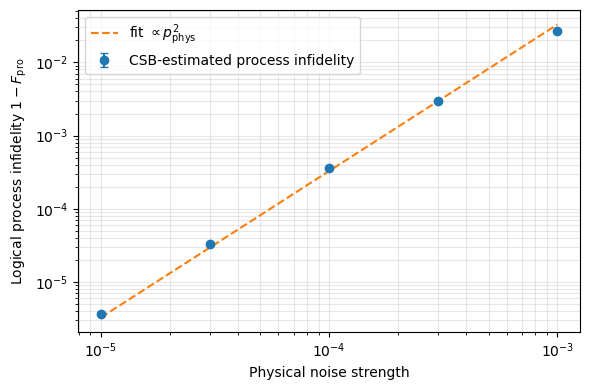

In [6]:

x = scaling_summary_df["physical_noise_strength"].to_numpy()
y = scaling_summary_df["process_infidelity_mean"].to_numpy()
yerr = scaling_summary_df["process_infidelity_std"].to_numpy()

fit_mask = (
    np.isfinite(x)
    & np.isfinite(y)
    & (x > 0)
    & (y > 0)
    & (x <= FIT_MAX_NOISE_STRENGTH)
)

x_fit = x[fit_mask]
y_fit = y[fit_mask]
yerr_fit = yerr[fit_mask]

basis = x_fit**2
weights = np.where(np.isfinite(yerr_fit) & (yerr_fit > 0), 1.0 / yerr_fit**2, 1.0)
A_quad = np.sum(weights * basis * y_fit) / np.sum(weights * basis**2)

slope, intercept = np.polyfit(np.log(x_fit), np.log(y_fit), 1)
B_power = np.exp(intercept)

scaling_fit_df = pd.DataFrame([{
    "target_gate": TARGET_GATE,
    "fit_max_noise_strength": FIT_MAX_NOISE_STRENGTH,
    "num_fit_points": int(np.sum(fit_mask)),
    "quadratic_coefficient_A": float(A_quad),
    "loglog_slope": float(slope),
    "loglog_prefactor_B": float(B_power),
}])

display(scaling_fit_df)



x_dense = np.logspace(np.log10(min(x)), np.log10(max(x)), 200)
y_quad_dense = A_quad * x_dense**2
y_power_dense = B_power * x_dense**slope

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    x,
    y,
    yerr=yerr,
    marker="o",
    capsize=3,
    linestyle="none",
    label="CSB-estimated process infidelity",
)

ax.plot(x_dense, y_quad_dense, "--", label=r"fit $\propto p_{\rm phys}^2$")
#ax.plot(x_dense, y_power_dense, ":", label=rf"log-log slope = {slope:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Physical noise strength")
ax.set_ylabel(r"Logical process infidelity $1-F_{\rm pro}$")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()

# if SAVE_PLOTS:
#     plt.savefig("phase_gate_process_infidelity_quadratic_scaling.pdf", bbox_inches="tight")

plt.show()


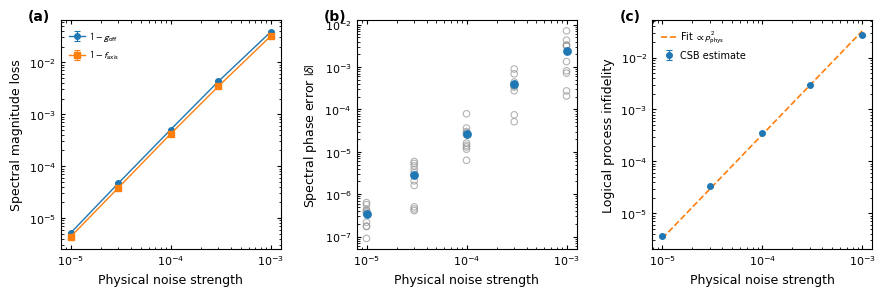

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================
FIT_MAX_NOISE_STRENGTH = globals().get(
    "FIT_MAX_NOISE_STRENGTH", 1e-4
)

SAVE_PLOTS = globals().get("SAVE_PLOTS", True)
PLOT_DPI = globals().get("PLOT_DPI", 600)
OUTPUT_PREFIX = "fig_phase_gate_ft_scaling"

# ============================================================
# Paper figure style
# ============================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",

    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,

    "axes.linewidth": 0.8,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "legend.frameon": False,

    "lines.linewidth": 1.1,
    "lines.markersize": 4.0,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# ============================================================
# Helpers
# ============================================================
def wrap_to_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2 * np.pi) - np.pi


def safe_log_yerr(y, yerr, lower_fraction=0.95):
    """
    Prevent lower error bars from crossing zero on a log-y axis.
    """
    if yerr is None:
        return None

    y = np.asarray(y, dtype=float)
    e = np.asarray(yerr, dtype=float)

    if not np.any(np.isfinite(e)):
        return None

    e = np.where(np.isfinite(e), e, 0.0)

    lower = np.minimum(
        e,
        lower_fraction * np.maximum(y, 1e-300),
    )
    upper = e

    return np.vstack([lower, upper])


def style_axis(ax):
    """
    Common manuscript axis formatting.
    """
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
    )
    ax.grid(False)


def add_panel_label(ax, label):
    ax.text(
        -0.15,
        1.05,
        label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left",
    )


# ============================================================
# Prepare data
# ============================================================
plot_df = scaling_summary_df.copy()
x = plot_df["physical_noise_strength"].to_numpy(dtype=float)

# ------------------------------------------------------------
# Phase-error summary
# ------------------------------------------------------------
if "abs_delta_theta_mean" not in plot_df.columns:

    if (
        "scaling_raw_df" in globals()
        and "delta_theta" in scaling_raw_df.columns
    ):
        tmp = scaling_raw_df.copy()

        tmp["delta_theta"] = wrap_to_pi(
            tmp["delta_theta"].to_numpy(dtype=float)
        )

        tmp["abs_delta_theta"] = np.abs(
            tmp["delta_theta"].to_numpy(dtype=float)
        )

        angle_summary = (
            tmp.groupby("physical_noise_strength")
            .agg(
                abs_delta_theta_mean=("abs_delta_theta", "mean"),
                abs_delta_theta_std=("abs_delta_theta", "std"),
            )
            .reset_index()
        )

        plot_df = plot_df.merge(
            angle_summary,
            on="physical_noise_strength",
            how="left",
        )

    else:
        plot_df["abs_delta_theta_mean"] = np.abs(
            wrap_to_pi(
                plot_df["delta_theta_mean"].to_numpy(dtype=float)
            )
        )

        if "delta_theta_std" in plot_df.columns:
            plot_df["abs_delta_theta_std"] = (
                plot_df["delta_theta_std"]
            )
        else:
            plot_df["abs_delta_theta_std"] = np.nan


# ------------------------------------------------------------
# Spectral magnitude losses
# ------------------------------------------------------------
g_off = plot_df["g_offdiag_mean"].to_numpy(dtype=float)
g_axis = plot_df["g_axis_mean"].to_numpy(dtype=float)

spectral_loss_off = 1.0 - g_off
spectral_loss_axis = 1.0 - g_axis

spectral_loss_off = np.where(
    spectral_loss_off > 0,
    spectral_loss_off,
    np.nan,
)

spectral_loss_axis = np.where(
    spectral_loss_axis > 0,
    spectral_loss_axis,
    np.nan,
)

spectral_loss_off_err = (
    plot_df["g_offdiag_std"].to_numpy(dtype=float)
    if "g_offdiag_std" in plot_df.columns
    else None
)

spectral_loss_axis_err = (
    plot_df["g_axis_std"].to_numpy(dtype=float)
    if "g_axis_std" in plot_df.columns
    else None
)


# ------------------------------------------------------------
# Process infidelity
# ------------------------------------------------------------
proc_inf = plot_df["process_infidelity_mean"].to_numpy(dtype=float)

proc_inf = np.where(
    proc_inf > 0,
    proc_inf,
    np.nan,
)

proc_inf_err = (
    plot_df["process_infidelity_std"].to_numpy(dtype=float)
    if "process_infidelity_std" in plot_df.columns
    else None
)


# ============================================================
# Repeat-level coherent phase data
# ============================================================
angle_raw_df = scaling_raw_df.copy()

angle_raw_df["delta_theta_wrapped"] = wrap_to_pi(
    angle_raw_df["delta_theta"].to_numpy(dtype=float)
)

angle_raw_df["abs_delta_theta"] = np.abs(
    angle_raw_df["delta_theta_wrapped"].to_numpy(dtype=float)
)

ANGLE_FLOOR = 1e-12

angle_raw_df["abs_delta_theta_plot"] = np.maximum(
    angle_raw_df["abs_delta_theta"].to_numpy(dtype=float),
    ANGLE_FLOOR,
)

angle_mean_df = (
    angle_raw_df
    .groupby("physical_noise_strength")
    .agg(
        abs_delta_theta_mean=("abs_delta_theta", "mean"),
        abs_delta_theta_std=("abs_delta_theta", "std"),
        n_repeats=("abs_delta_theta", "count"),
    )
    .reset_index()
    .sort_values("physical_noise_strength")
)

angle_mean_df["abs_delta_theta_mean_plot"] = np.maximum(
    angle_mean_df["abs_delta_theta_mean"].to_numpy(dtype=float),
    ANGLE_FLOOR,
)


# ============================================================
# Quadratic fit for panel (c)
# Fit only p <= FIT_MAX_NOISE_STRENGTH
# ============================================================
fit_mask = (
    np.isfinite(x)
    & np.isfinite(proc_inf)
    & (x > 0)
    & (proc_inf > 0)
    & (x <= FIT_MAX_NOISE_STRENGTH)
)

x_fit = x[fit_mask]
y_fit = proc_inf[fit_mask]

if proc_inf_err is not None:
    yerr_fit = proc_inf_err[fit_mask]
else:
    yerr_fit = None

if len(x_fit) == 0:
    raise ValueError(
        "No points satisfy the quadratic-fit mask. "
        "Increase FIT_MAX_NOISE_STRENGTH or check the data."
    )

basis = x_fit**2

if (
    yerr_fit is not None
    and np.any(np.isfinite(yerr_fit) & (yerr_fit > 0))
):
    weights = np.where(
        np.isfinite(yerr_fit) & (yerr_fit > 0),
        1.0 / yerr_fit**2,
        0.0,
    )

    A_quad = (
        np.sum(weights * basis * y_fit)
        / np.sum(weights * basis**2)
    )

else:
    A_quad = (
        np.sum(basis * y_fit)
        / np.sum(basis**2)
    )

x_dense_fit = np.logspace(
    np.log10(np.min(x_fit)),
    np.log10(np.max(x_fit)),
    200,
)

y_quad_fit = A_quad * x_dense_fit**2


# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(8.8, 2.9),
)


# ============================================================
# (a) Spectral magnitude loss
# ============================================================
ax = axes[0]

ax.errorbar(
    x,
    spectral_loss_off,
    yerr=safe_log_yerr(
        spectral_loss_off,
        spectral_loss_off_err,
    ),
    fmt="o-",
    linewidth=1.0,
    markersize=4.0,
    capsize=2.0,
    capthick=0.8,
    elinewidth=0.8,
    label=r"$1-g_{\rm off}$",
)

ax.errorbar(
    x,
    spectral_loss_axis,
    yerr=safe_log_yerr(
        spectral_loss_axis,
        spectral_loss_axis_err,
    ),
    fmt="s-",
    linewidth=1.0,
    markersize=3.8,
    capsize=2.0,
    capthick=0.8,
    elinewidth=0.8,
    label=r"$1-f_{\rm axis}$",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Physical noise strength")
ax.set_ylabel("Spectral magnitude loss")

ax.legend(
    loc="best",
    handlelength=1.6,
    handletextpad=0.4,
)

style_axis(ax)
add_panel_label(ax, "(a)")


# ============================================================
# (b) Coherent spectral phase error
# repeats: hollow markers
# mean: filled markers
# no connecting lines, no error bars, no x-jitter
# ============================================================
ax = axes[1]

# Individual repeats: all repeats at the exact same physical-noise value
for p, sub in angle_raw_df.groupby(
    "physical_noise_strength",
    sort=True,
):
    x_repeat = np.full(len(sub), float(p))

    ax.scatter(
        x_repeat,
        sub["abs_delta_theta_plot"],
        s=22,
        facecolors="none",
        edgecolors="0.60",
        linewidths=0.8,
        alpha=0.75,
        zorder=1,
    )

# Mean: filled marker
ax.scatter(
    angle_mean_df["physical_noise_strength"],
    angle_mean_df["abs_delta_theta_mean_plot"],
    s=28,
    zorder=3,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Physical noise strength")
ax.set_ylabel(r"Spectral phase error $|\delta|$")

style_axis(ax)
add_panel_label(ax, "(b)")


# ============================================================
# (c) Logical process infidelity
# ============================================================
ax = axes[2]

ax.errorbar(
    x,
    proc_inf,
    yerr=safe_log_yerr(
        proc_inf,
        proc_inf_err,
    ),
    fmt="o",
    linestyle="none",
    markersize=4.0,
    capsize=2.0,
    capthick=0.8,
    elinewidth=0.8,
    label="CSB estimate",
    zorder=3,
)

ax.plot(
    x_dense_fit,
    y_quad_fit,
    linestyle="--",
    linewidth=1.2,
    label=r"Fit $\propto p_{\rm phys}^{2}$",
    zorder=2,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Physical noise strength")
ax.set_ylabel("Logical process infidelity")

ax.legend(
    loc="best",
    handlelength=1.6,
    handletextpad=0.4,
)

style_axis(ax)
add_panel_label(ax, "(c)")


# ============================================================
# Layout
# ============================================================
fig.tight_layout(
    pad=0.6,
    w_pad=1.5,
)


# ============================================================
# Save
# ============================================================
fig.savefig(
        f"phase_gate_ft_scaling.pdf",
        bbox_inches="tight",
    )


plt.show()

## Optional: plot raw CSB signals at selected noise strengths

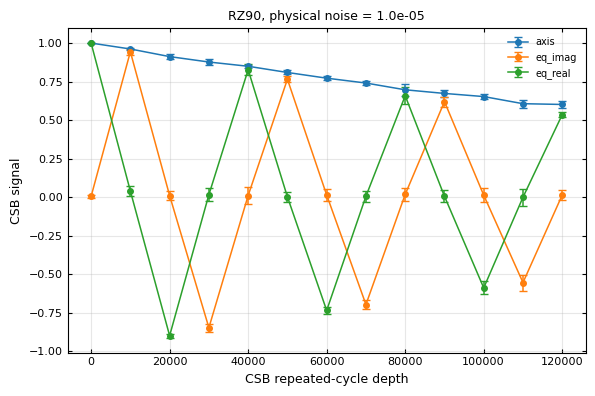

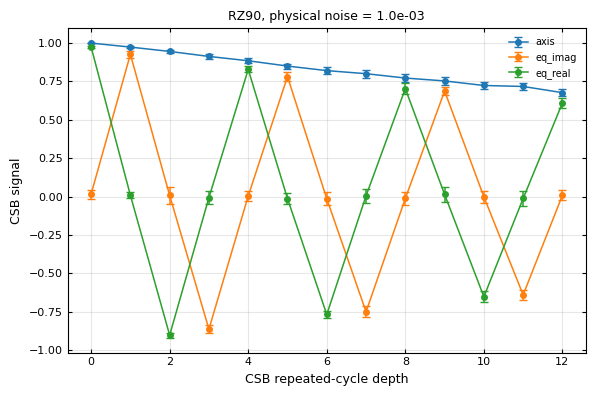

In [11]:

def plot_csb_signals_for_noise(csb_all_df, noise_strength, target_gate=TARGET_GATE):
    sub = csb_all_df[
        np.isclose(csb_all_df["physical_noise_strength"], noise_strength)
        & (csb_all_df["target_gate"] == target_gate)
    ].copy()

    if len(sub) == 0:
        raise ValueError(f"No data for noise_strength={noise_strength}")

    summary = (
        sub.groupby(["branch", "depth"])
        .agg(mean_of_mean=("mean", "mean"), std_of_mean=("mean", "std"))
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(6, 4))

    for branch, bsub in summary.groupby("branch"):
        ax.errorbar(
            bsub["depth"],
            bsub["mean_of_mean"],
            yerr=bsub["std_of_mean"],
            marker="o",
            capsize=3,
            label=branch,
        )

    ax.set_xlabel("CSB repeated-cycle depth")
    ax.set_ylabel("CSB signal")
    ax.set_title(f"{target_gate}, physical noise = {noise_strength:.1e}")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_csb_signals_for_noise(scaling_csb_raw_df, NOISE_REP_SCHEDULE[0]["p"])
plot_csb_signals_for_noise(scaling_csb_raw_df, NOISE_REP_SCHEDULE[-1]["p"])
